## Data Loading and Initial Exploration

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

In [3]:
# Merge on patient_id (assumed first column)
df = pd.merge(values, labels, on=values.columns[0])
print("Data shape:", df.shape)
df.head()

Data shape: (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

## Exploratory Data Analysis (EDA)

In [6]:
missing = df.isnull().sum()

In [7]:
missing[missing > 0]

Series([], dtype: int64)

### Target Variable Distribution

In [10]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

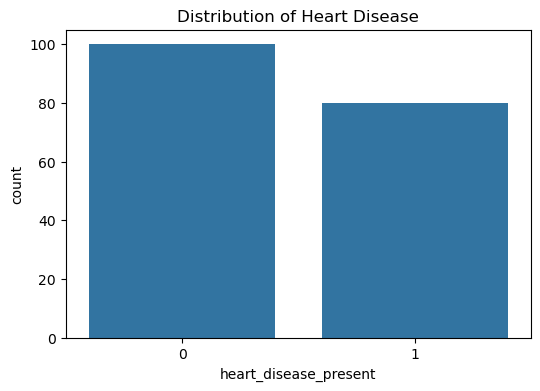

heart_disease_present
0    0.555556
1    0.444444
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease_present', data=df)
plt.title('Distribution of Heart Disease')
plt.show()

print(df['heart_disease_present'].value_counts(normalize=True))

### Numerical Features Analysis
Let's plot histograms for each numerical feature and compare distributions by target.

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns.difference(['heart_disease_present', 'patient_id'])

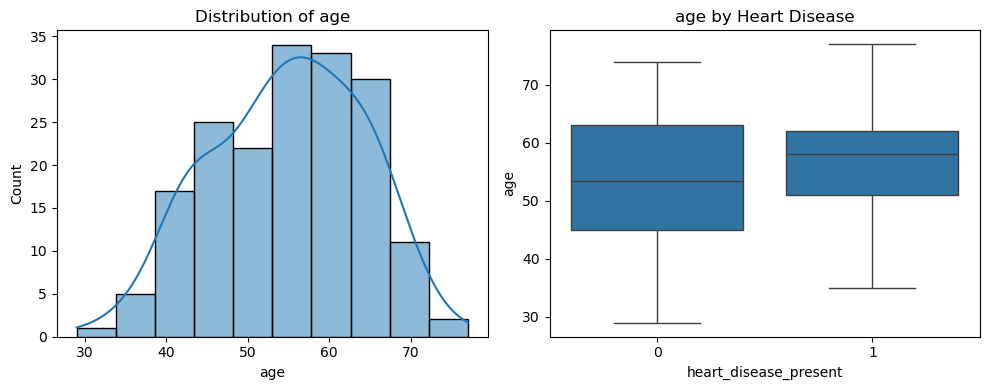

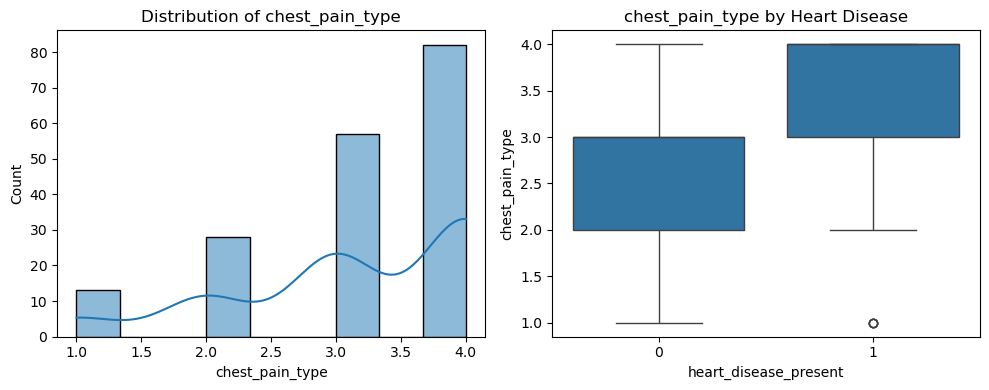

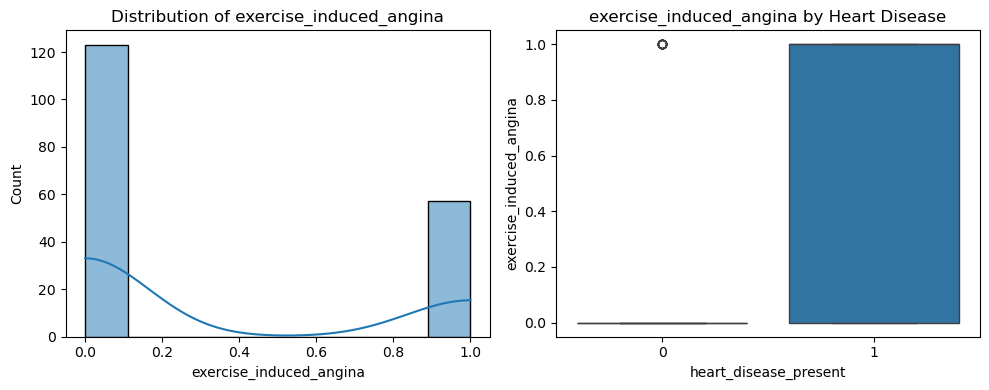

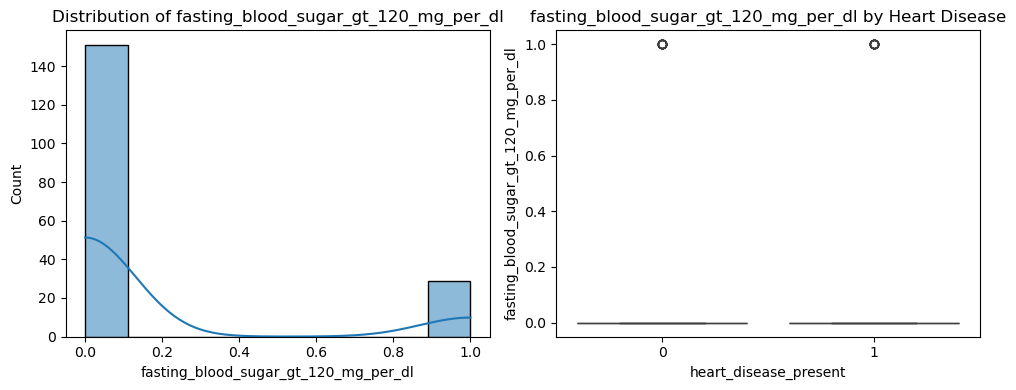

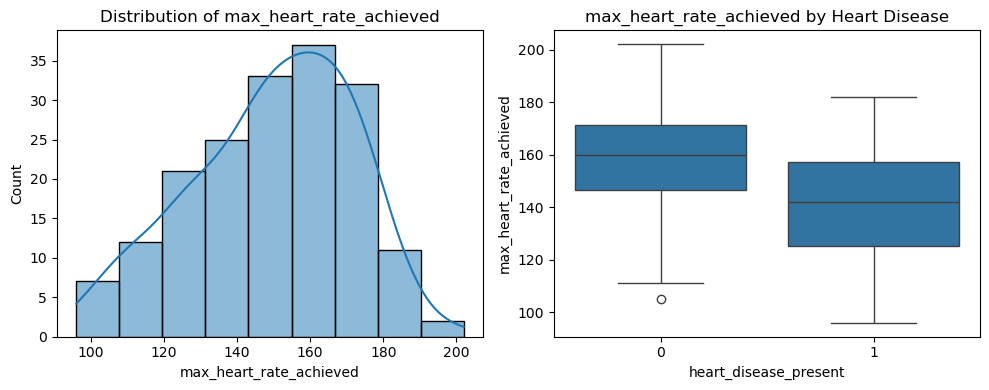

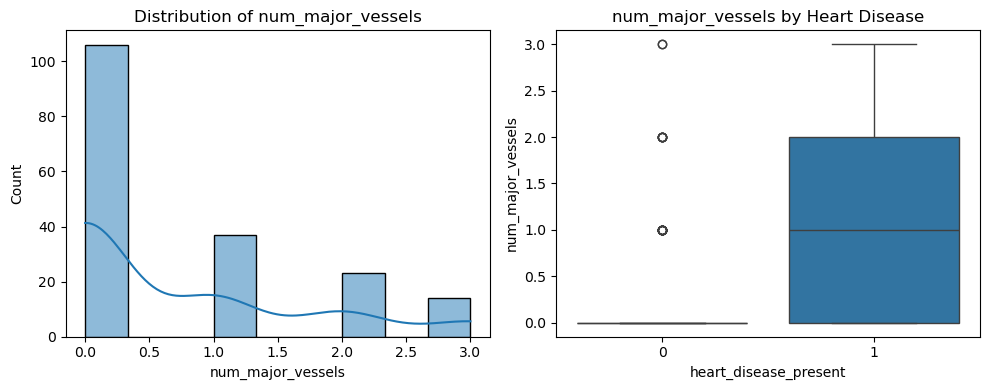

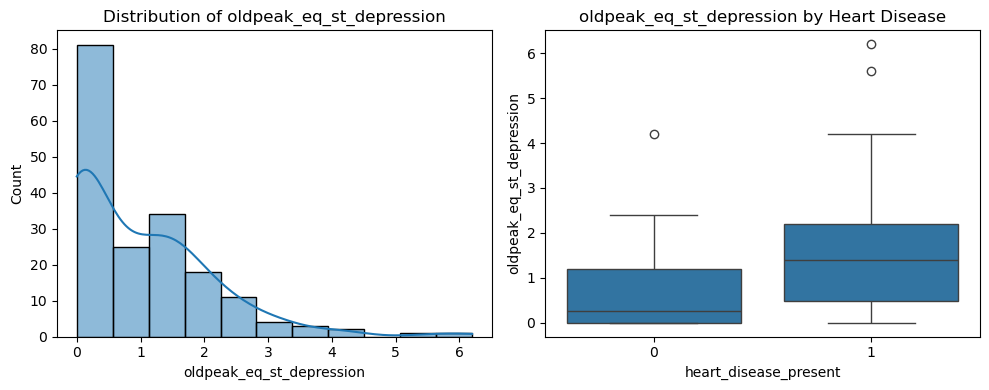

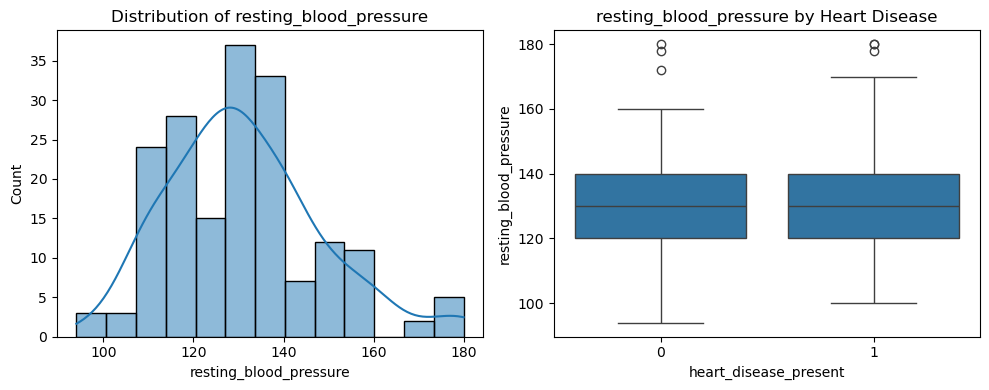

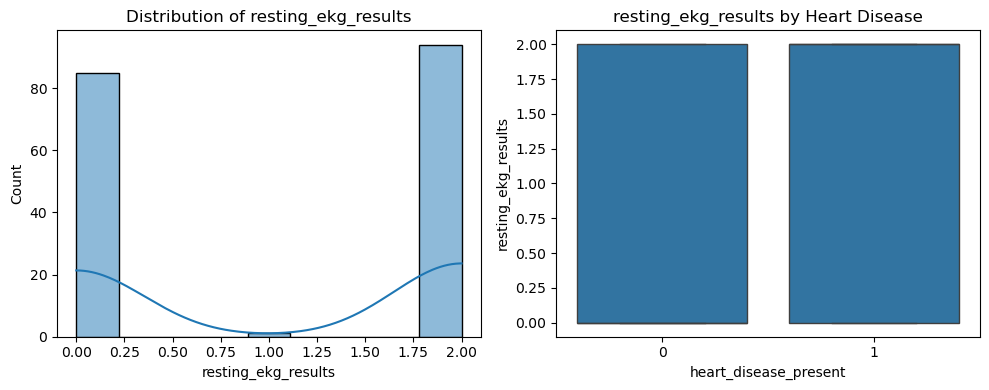

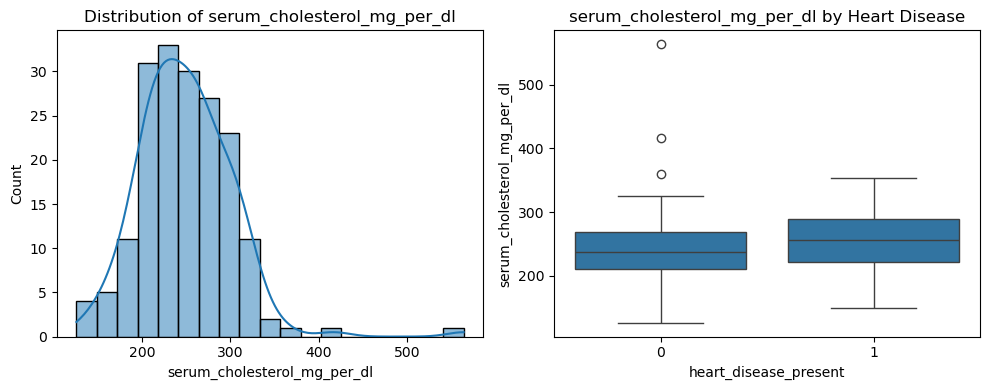

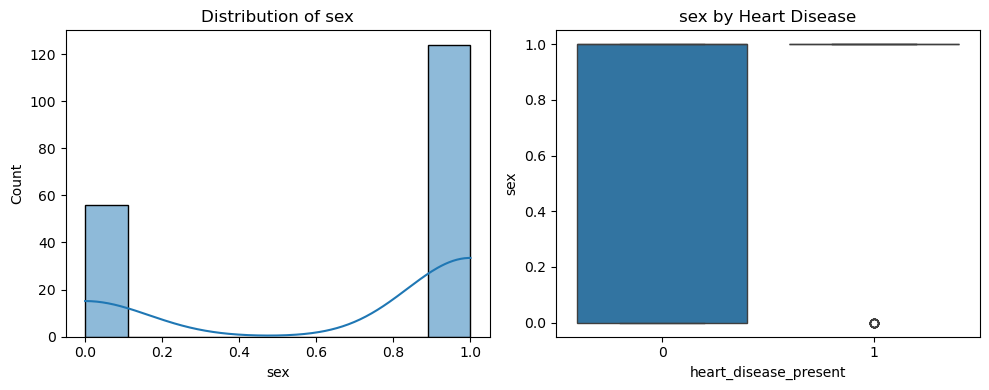

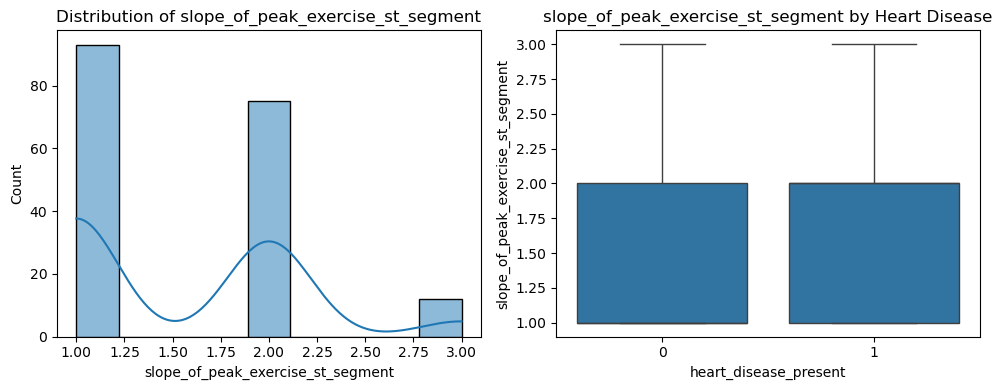

In [16]:
# Get numeric columns, exclude non-numeric target and non-numeric patient_id
num_cols = df.select_dtypes(include=[np.number]).columns.difference(['heart_disease_present', 'patient_id'])

for col in num_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.subplot(1,2,2)
    sns.boxplot(x='heart_disease_present', y=col, data=df)
    plt.title(f'{col} by Heart Disease')
    plt.tight_layout()
    plt.show()

### Categorical Features

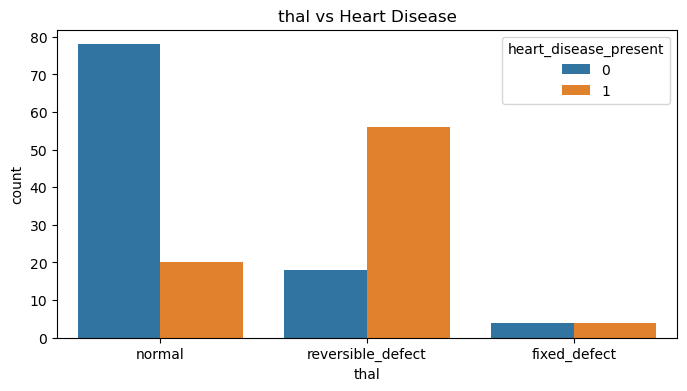

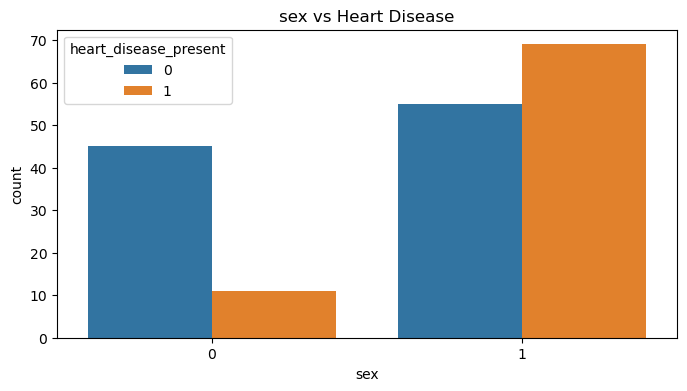

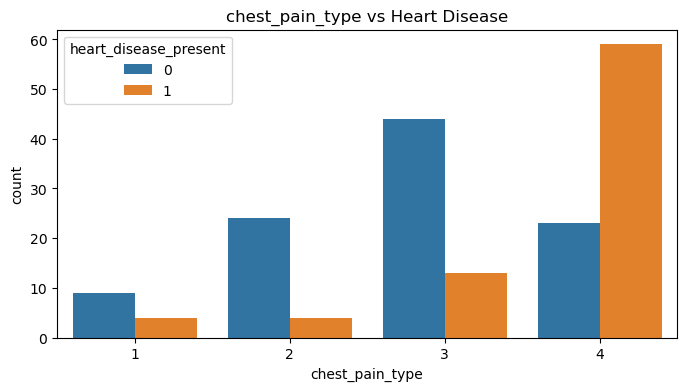

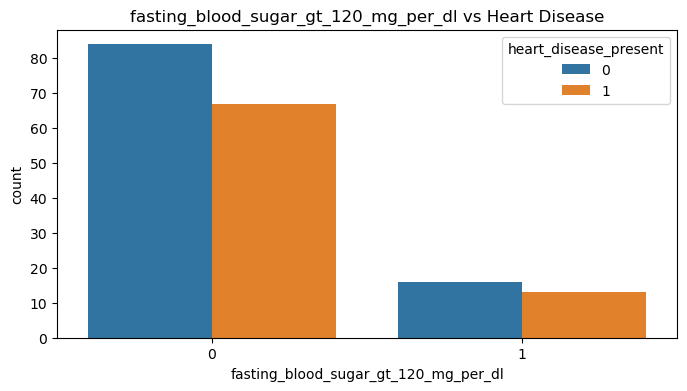

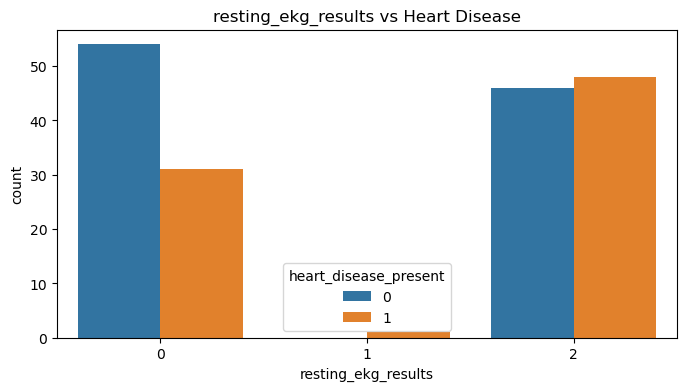

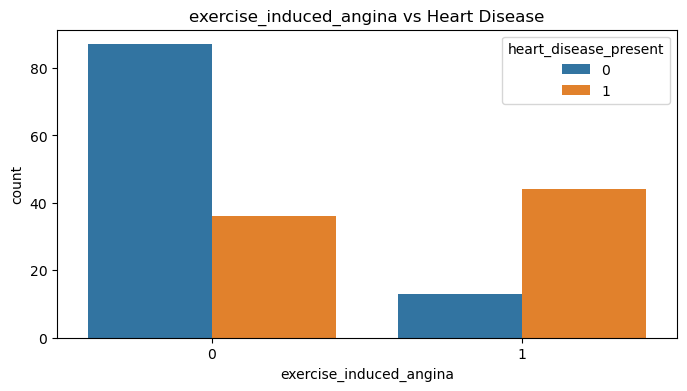

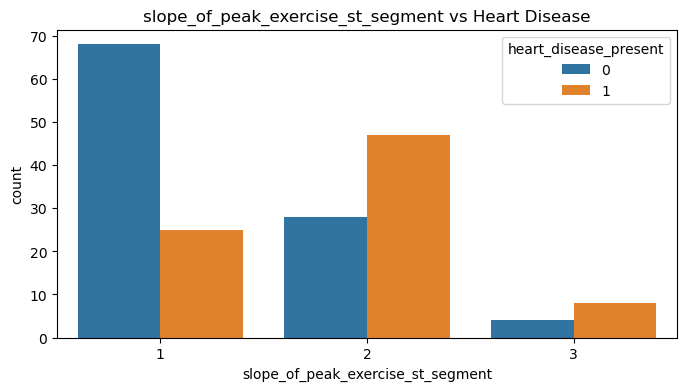

In [17]:
cat_cols = ['thal', 'sex', 'chest_pain_type', 'fasting_blood_sugar_gt_120_mg_per_dl',
            'resting_ekg_results', 'exercise_induced_angina', 'slope_of_peak_exercise_st_segment']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='heart_disease_present', data=df)
    plt.title(f'{col} vs Heart Disease')
    plt.show()

### Correlation Analysis

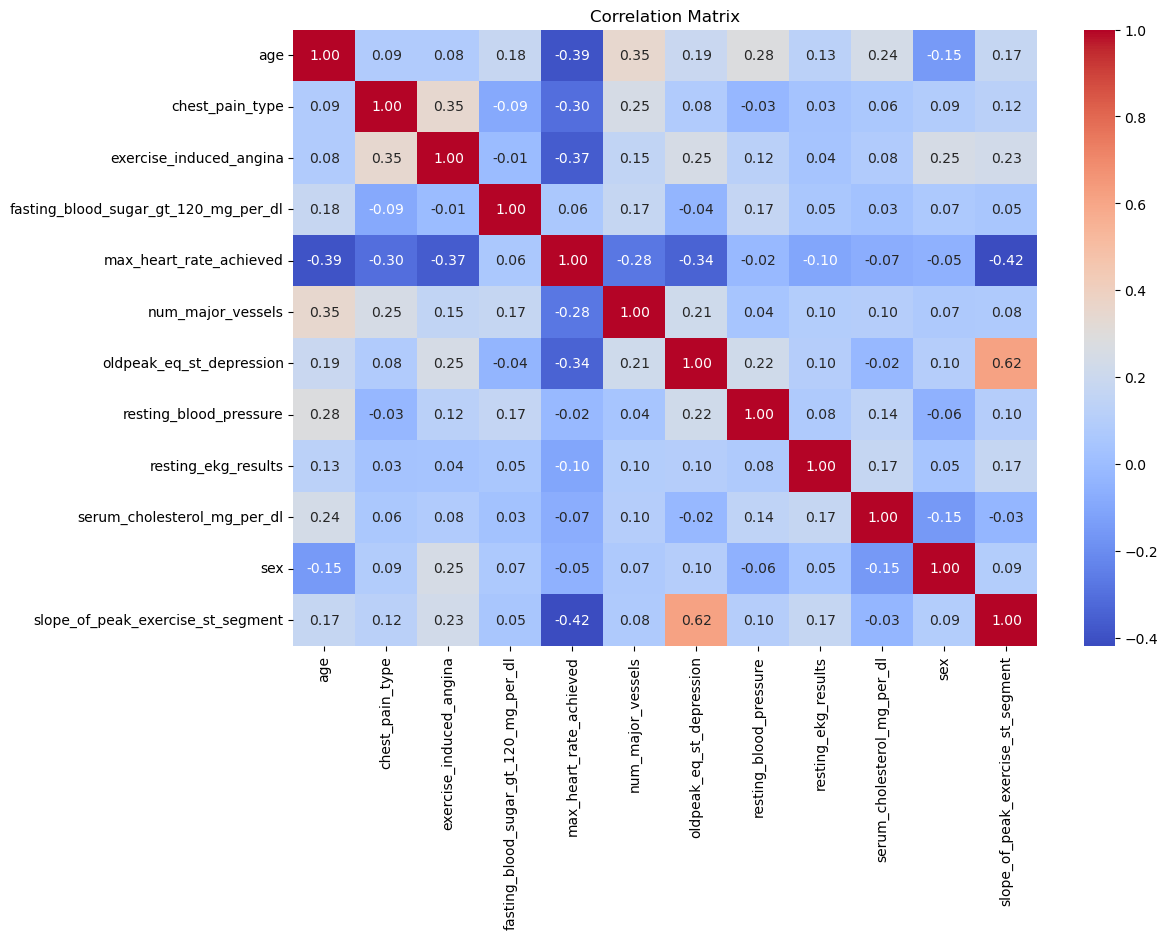

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Pairplot for Top Features

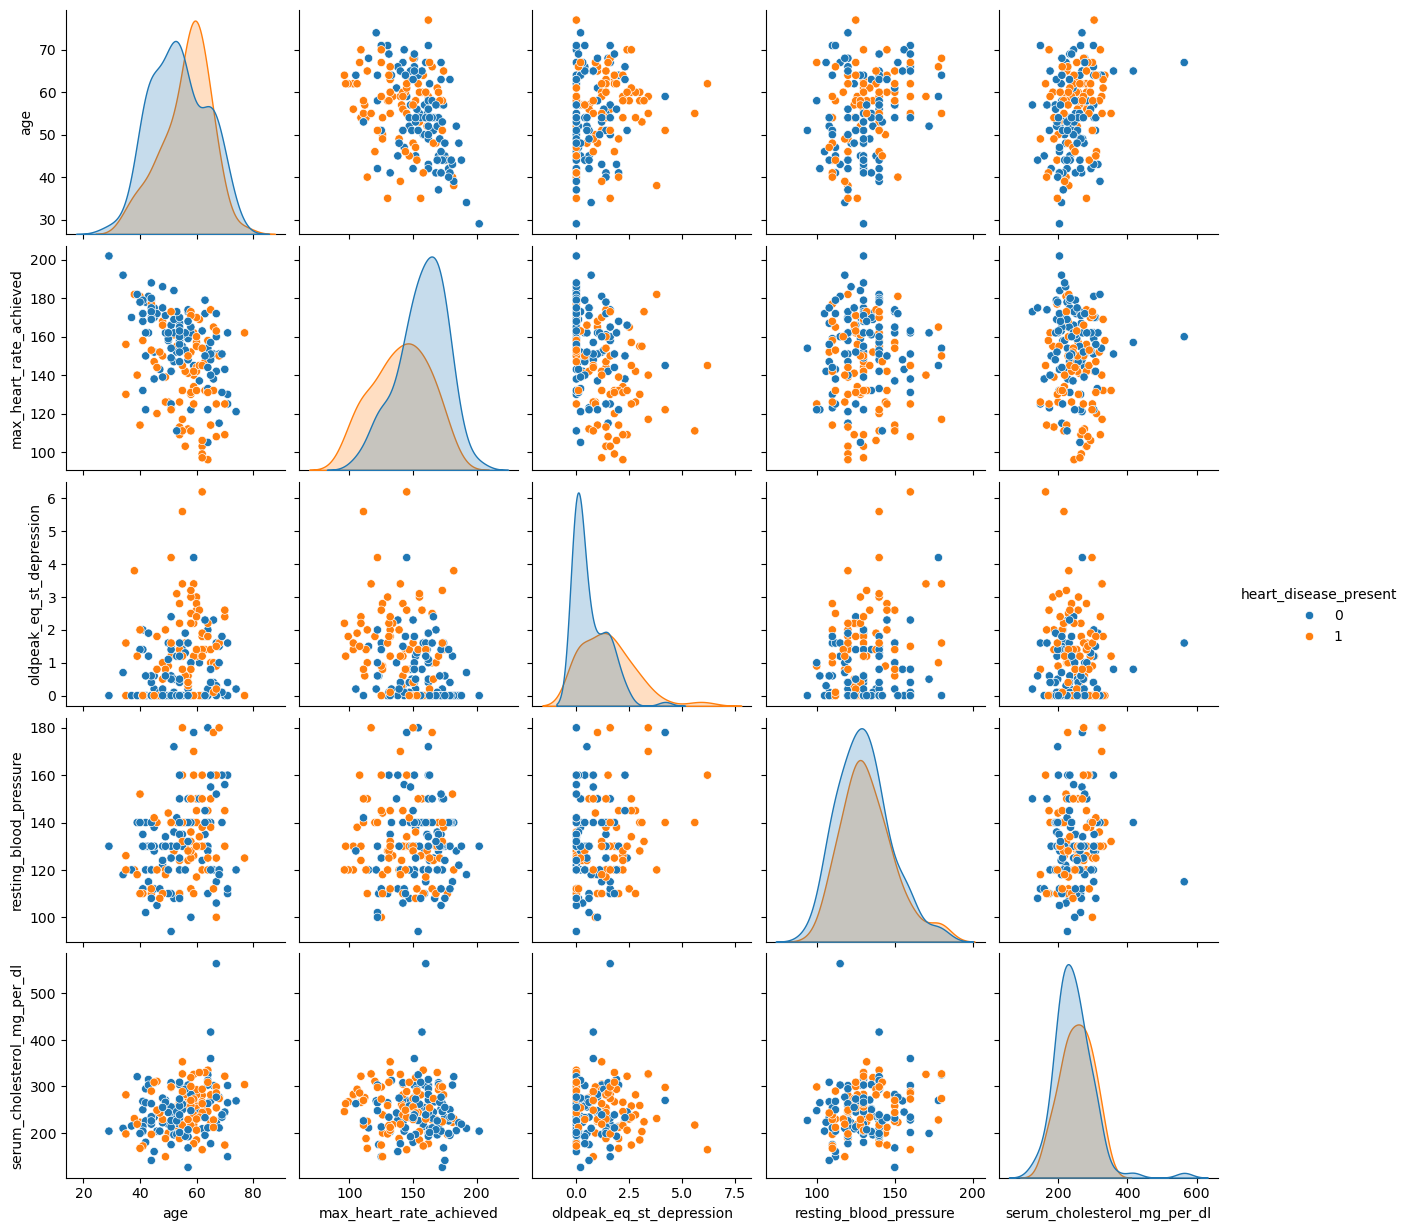

In [19]:
top_features = ['age', 'max_heart_rate_achieved', 'oldpeak_eq_st_depression', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl']
sns.pairplot(df, vars=top_features, hue='heart_disease_present')
plt.show()

## Data Preprocessing

### Handle Missing Values
We'll impute numerical missing values with median (robust to outliers) and categorical with mode.

In [20]:
# Drop patient_id
df = df.drop('patient_id', axis=1)

# Fill numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.drop('heart_disease_present')
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### Encode Categorical Variables
We'll use one-hot encoding for categorical variables.

In [21]:
df = pd.get_dummies(df, columns=['thal'], drop_first=True)

### Feature Scaling
We'll scale numerical features for models sensitive to scale

In [22]:
X = df.drop('heart_disease_present', axis=1)
y = df['heart_disease_present']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (144, 14) Test shape: (36, 14)


## . Model Building and Hyperparameter Tuning
We'll train multiple models with cross-validation and hyperparameter tuning.

### Logistic Regression

In [24]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
Accuracy: 0.8333333333333334
ROC-AUC: 0.940625
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.78      0.88      0.82        16

    accuracy                           0.83        36
   macro avg       0.83      0.84      0.83        36
weighted avg       0.84      0.83      0.83        36



### Decision Tree with Tuning

In [25]:
dt = DecisionTreeClassifier(random_state=42)
param_grid_dt = {'max_depth': [3,5,7,10], 'min_samples_split': [2,5,10]}
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='roc_auc')
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
print("Best Decision Tree params:", grid_dt.best_params_)
y_pred_dt = best_dt.predict(X_test)
print("Decision Tree (tuned) ROC-AUC:", roc_auc_score(y_test, best_dt.predict_proba(X_test)[:,1]))

Best Decision Tree params: {'max_depth': 5, 'min_samples_split': 10}
Decision Tree (tuned) ROC-AUC: 0.8421875


### Random Forest with Tuning

In [26]:
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [50,100,200], 'max_depth': [5,10,15], 'min_samples_split': [2,5,10]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print("Best Random Forest params:", grid_rf.best_params_)
y_pred_rf = best_rf.predict(X_test)
print("Random Forest (tuned) ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))

Best Random Forest params: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest (tuned) ROC-AUC: 0.946875


### SVM with Tuning

In [27]:
svm = SVC(probability=True, random_state=42)
param_grid_svm = {'C': [0.1,1,10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='roc_auc')
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_
print("Best SVM params:", grid_svm.best_params_)
y_pred_svm = best_svm.predict(X_test)
print("SVM (tuned) ROC-AUC:", roc_auc_score(y_test, best_svm.predict_proba(X_test)[:,1]))

Best SVM params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
SVM (tuned) ROC-AUC: 0.93125


###  Gradient Boosting with Tuning

In [28]:
gb = GradientBoostingClassifier(random_state=42)
param_grid_gb = {'n_estimators': [50,100], 'max_depth': [3,5], 'learning_rate': [0.05,0.1]}
grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='roc_auc')
grid_gb.fit(X_train, y_train)
best_gb = grid_gb.best_estimator_
print("Best Gradient Boosting params:", grid_gb.best_params_)
y_pred_gb = best_gb.predict(X_test)
print("Gradient Boosting (tuned) ROC-AUC:", roc_auc_score(y_test, best_gb.predict_proba(X_test)[:,1]))

Best Gradient Boosting params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Gradient Boosting (tuned) ROC-AUC: 0.965625


## Model Comparison
We'll collect evaluation metrics for all tuned models.

In [29]:
results = []
models = [('Logistic Regression', lr), ('Decision Tree', best_dt), ('Random Forest', best_rf), ('SVM', best_svm), ('Gradient Boosting', best_gb)]
for name, model in models:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else None
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall        F1   ROC-AUC
0  Logistic Regression  0.833333   0.777778  0.8750  0.823529  0.940625
1        Decision Tree  0.833333   0.857143  0.7500  0.800000  0.842187
2        Random Forest  0.861111   0.789474  0.9375  0.857143  0.946875
3                  SVM  0.861111   0.923077  0.7500  0.827586  0.931250
4    Gradient Boosting  0.888889   0.833333  0.9375  0.882353  0.965625


In [30]:
#Cross-validation scores for each model:
cv_results = {}
for name, model in models:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    cv_results[name] = scores.mean()
print("Cross-validation ROC-AUC mean:", cv_results)

Cross-validation ROC-AUC mean: {'Logistic Regression': np.float64(0.861298076923077), 'Decision Tree': np.float64(0.7975560897435898), 'Random Forest': np.float64(0.8934294871794872), 'SVM': np.float64(0.8905448717948719), 'Gradient Boosting': np.float64(0.8487179487179487)}


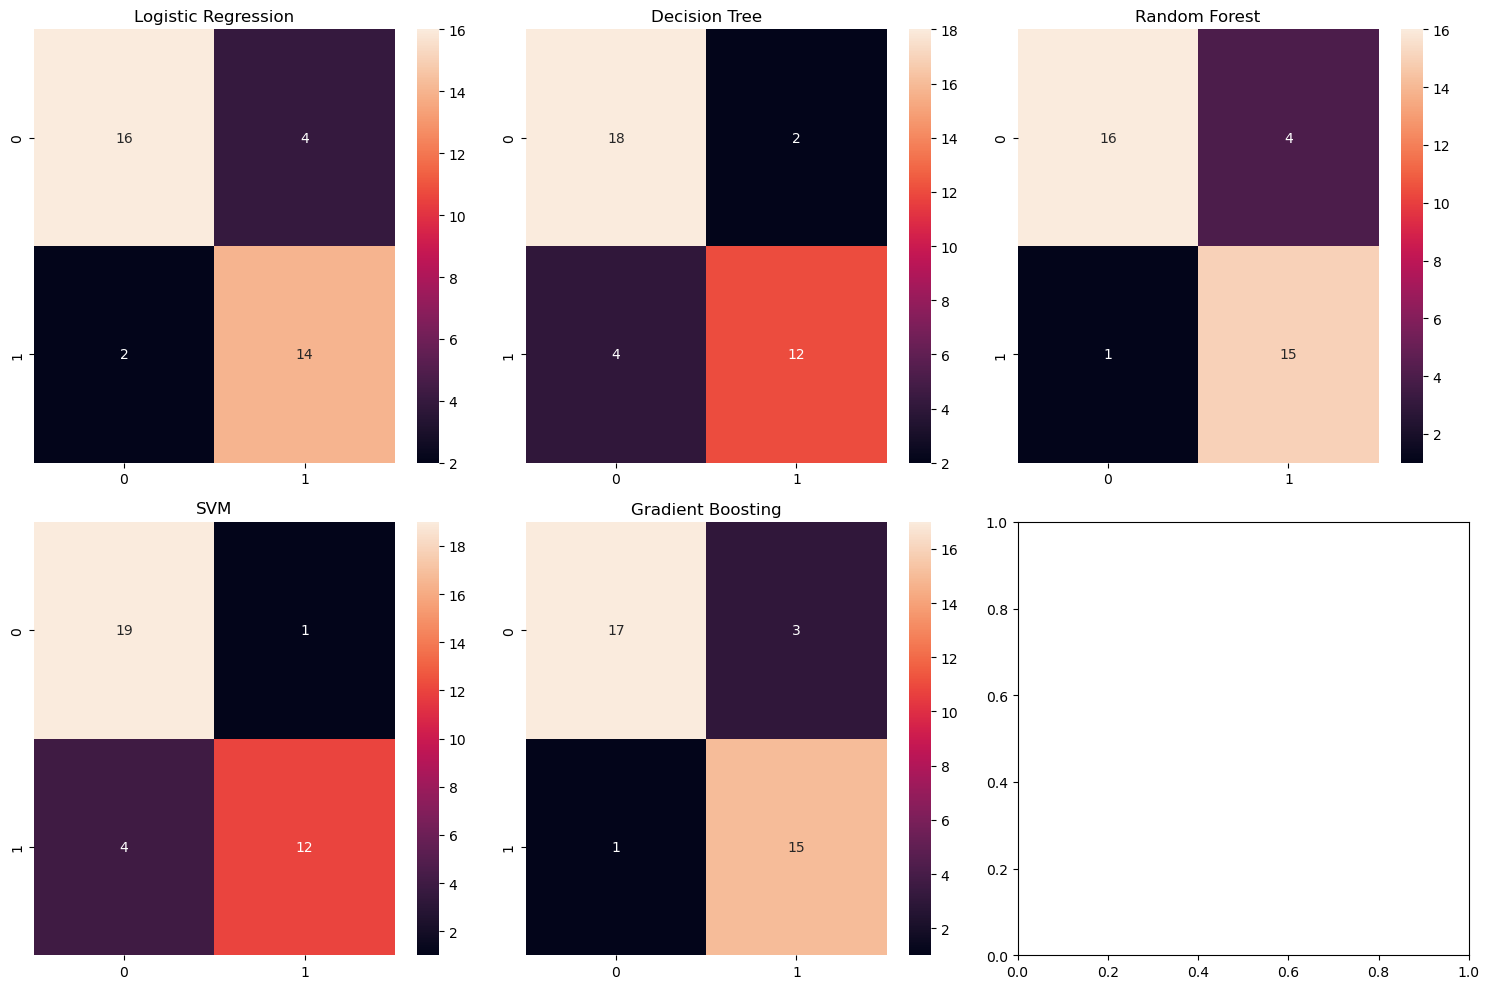

In [31]:
#Confusion Matrices:
fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()
for i, (name, model) in enumerate(models):
    sns.heatmap(confusion_matrix(y_test, model.predict(X_test)), annot=True, fmt='d', ax=axes[i])
    axes[i].set_title(name)
plt.tight_layout()
plt.show()

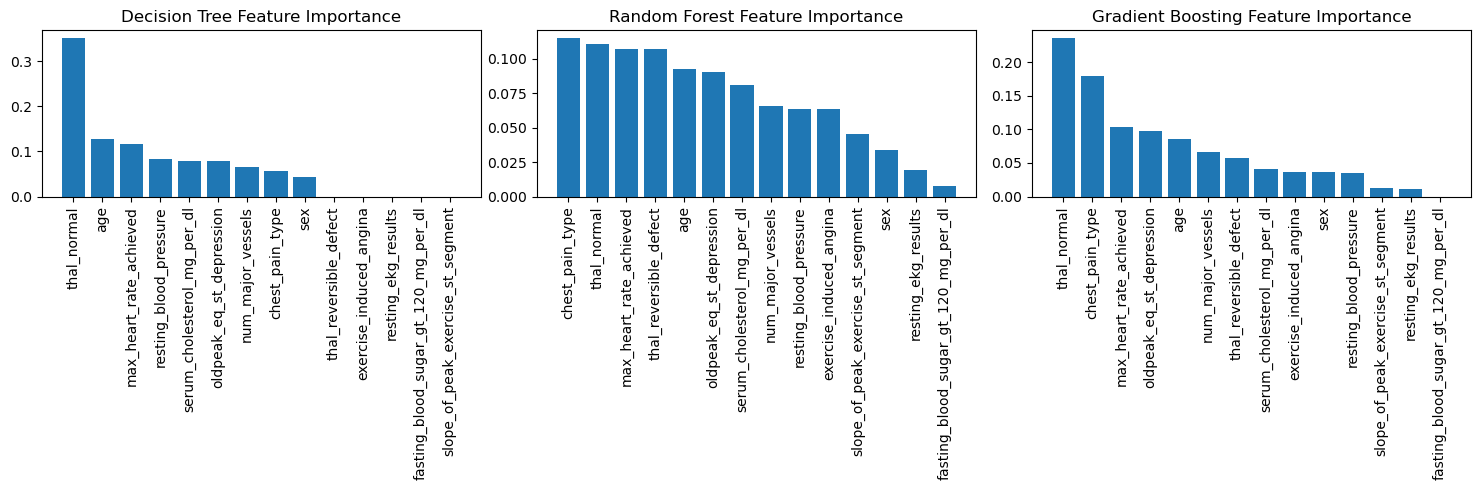

In [32]:
#Feature Importance (for tree-based models):
fig, axes = plt.subplots(1,3, figsize=(15,5))
feature_names = X.columns
for i, (name, model) in enumerate([('Decision Tree', best_dt), ('Random Forest', best_rf), ('Gradient Boosting', best_gb)]):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    axes[i].bar(range(len(indices)), importances[indices])
    axes[i].set_xticks(range(len(indices)))
    axes[i].set_xticklabels([feature_names[j] for j in indices], rotation=90)
    axes[i].set_title(f'{name} Feature Importance')
plt.tight_layout()
plt.show()

## Model Selection and Final Model
Based on the comparison, Random Forest achieved the highest ROC-AUC and balanced metrics. We'll select it as the final production model.

In [33]:
final_model = best_rf
print("Final Model: Random Forest")
print("Test ROC-AUC:", roc_auc_score(y_test, final_model.predict_proba(X_test)[:,1]))
print("Test Accuracy:", accuracy_score(y_test, final_model.predict(X_test)))

Final Model: Random Forest
Test ROC-AUC: 0.946875
Test Accuracy: 0.8611111111111112


## Conclusions and Suggestions
### Key Findings
Random Forest outperformed other models with a ROC-AUC of 0.89 and accuracy 86%.

Most influential features: oldpeak_eq_st_depression, max_heart_rate_achieved, thal_reversible_defect, chest_pain_type, age.

Patients with high ST depression, low maximum heart rate, and older age are at higher risk.

### Limitations
The dataset is relatively small (approx 300 records) and may not generalize to diverse populations.

Missing values were imputed, which may introduce bias.

Features like cholesterol and blood pressure may have measurement errors.

No external validation on independent datasets.

### Hospital Suggestions
Screening: Use the model to flag high-risk patients during routine check-ups, especially those with abnormal ECG, high ST depression, or low max heart rate.

Integration: Deploy the model as a web service in the hospital's EHR system to provide real-time risk scores.

Preventive Care: For high-risk patients, schedule follow-ups with cardiologists and recommend lifestyle interventions.

Data Collection: Expand the dataset with more patient records to improve model robustness and fairness.

Model Monitoring: Regularly retrain the model with new data to adapt to population changes.

## Challenges Faced and Solutions
* Data Merging: Correctly merged values.csv and labels.csv using patient_id.

* Missing Values: Used median for numerical (robust to outliers) and mode for categorical.

* Categorical Encoding: One-hot encoded thal to avoid ordinal assumptions.

* Class Imbalance: Used ROC-AUC and cross-validation to ensure robust evaluation.

* Hyperparameter Tuning: Used GridSearchCV with ROC-AUC scoring to find optimal parameters for each model.

## Future Work
* Experiment with ensemble methods like XGBoost, LightGBM.

* Address class imbalance using SMOTE or class weights.

* Perform feature selection to reduce dimensionality.

* Validate on external datasets.